✅ Data loaded successfully
Shape: (10000, 15)
✅ Numeric columns selected: ['customer_id', 'product_id', 'price', 'quantity']


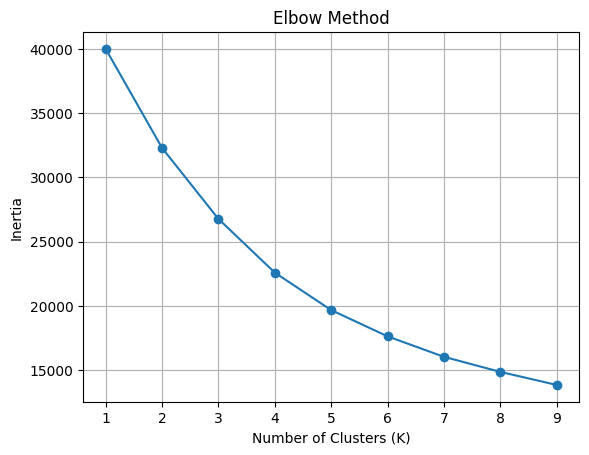

✅ Clustering done


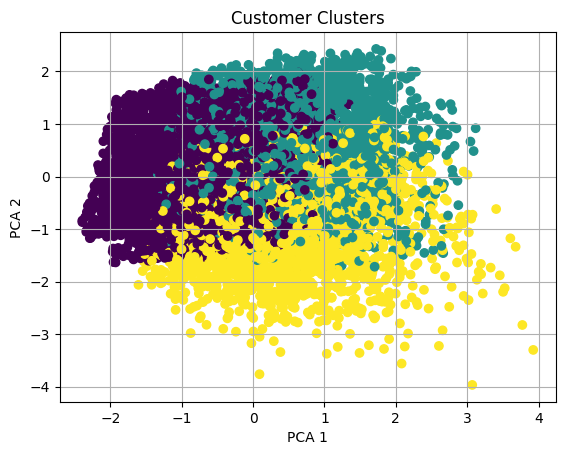

✅ File saved as clustered_output.csv


In [2]:
# ==============================
# 1. IMPORTS
# ==============================
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATA (SAFE)
# ==============================
file_path = r"/home/pabodasanduni/Desktop/New Folder/Deep-Thinkers-ML-Project-main/project/ecommerce_orders_raw_data.csv"

# Check file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found ❌: {file_path}")

# Load dataset
try:
    df = pd.read_csv(file_path)
    print("✅ Data loaded successfully")
    print("Shape:", df.shape)
except Exception as e:
    print("❌ Error loading file:", e)
    exit()

# ==============================
# 3. SELECT NUMERIC FEATURES
# ==============================
features = df.select_dtypes(include=['int64', 'float64'])

if features.empty:
    raise ValueError("❌ No numeric columns found!")

print("✅ Numeric columns selected:", features.columns.tolist())

# ==============================
# 4. HANDLE MISSING VALUES
# ==============================
features = features.fillna(features.mean())

# ==============================
# 5. SCALE DATA
# ==============================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# ==============================
# 6. ELBOW METHOD
# ==============================
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

# ==============================
# 7. APPLY KMEANS
# ==============================
optimal_k = 3  # change based on elbow

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print("✅ Clustering done")

# ==============================
# 8. PCA VISUALIZATION
# ==============================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure()
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Clusters")
plt.grid()
plt.show()

# ==============================
# 9. SAVE OUTPUT
# ==============================
output_file = "clustered_output.csv"
df.to_csv(output_file, index=False)

print(f"✅ File saved as {output_file}")